# Model Evaluation: A Comprehensive Guide

Choosing the right evaluation metric is as important as choosing the right model. Different metrics are suited for different types of problems (binary vs. multiclass, balanced vs. imbalanced datasets, regression vs. classification).

In this notebook, we'll cover:
1. Classification metrics: Accuracy, Precision, Recall, F1, ROC-AUC
2. Regression metrics: MSE, RMSE, MAE, R²
3. Understanding the confusion matrix
4. When to use which metric
5. Evaluation of imbalanced datasets

# Simple Explanation: What Does the Code Below Do?

Imagine a doctor testing patients for a rare disease that affects 1% of the population. A model that always predicts 'no disease' would be 99% accurate — but it would miss every single sick patient! This is why we need metrics beyond just accuracy.

**Key Classification Metrics**:
- **Accuracy**: (TP + TN) / Total — Good for balanced datasets.
- **Precision**: TP / (TP + FP) — Of all predicted positives, how many were correct? (Avoid false alarms)
- **Recall/Sensitivity**: TP / (TP + FN) — Of all actual positives, how many did we catch? (Medical diagnosis!)
- **F1-Score**: Harmonic mean of Precision and Recall — Balances both.
- **ROC-AUC**: Area under the ROC curve — Model's ability to distinguish classes.

**Key Regression Metrics**:
- **MSE**: Mean Squared Error — Penalizes large errors heavily.
- **RMSE**: Root MSE — In the same units as the target.
- **MAE**: Mean Absolute Error — More robust to outliers.
- **R²**: Proportion of variance explained — 1.0 = perfect, 0 = baseline.

Here's what the code does:
1. Computes and explains all major evaluation metrics.
2. Visualizes ROC curves, precision-recall curves, and confusion matrices.
3. Shows why accuracy fails on imbalanced datasets.

In short: Picking the right metric is crucial — accuracy alone can be misleading!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Understanding the Confusion Matrix

The foundation of classification metrics:
- **TP** (True Positive): Predicted positive, actually positive.
- **TN** (True Negative): Predicted negative, actually negative.
- **FP** (False Positive): Predicted positive, actually negative. (Type I Error)
- **FN** (False Negative): Predicted negative, actually positive. (Type II Error)

=== Classification Metrics ===
Accuracy:  0.9649
Precision: 0.9589  (of all predicted malignant, % actually malignant)
Recall:    0.9859   (of all actual malignant, % we caught)
F1-Score:  0.9722   (harmonic mean of precision and recall)

Full Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



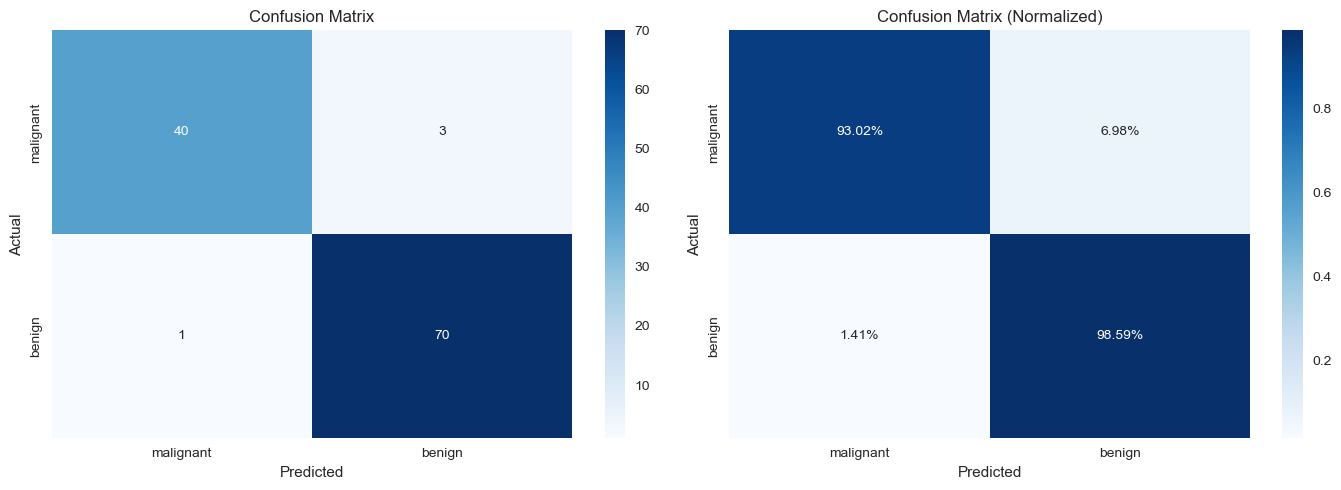

In [3]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
class_names = cancer.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Compute all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('=== Classification Metrics ===')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}  (of all predicted malignant, % actually malignant)')
print(f'Recall:    {recall:.4f}   (of all actual malignant, % we caught)')
print(f'F1-Score:  {f1:.4f}   (harmonic mean of precision and recall)')
print(f'\nFull Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion matrix with percentage
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 3. ROC Curve, Precision-Recall Curve, and Regression Metrics

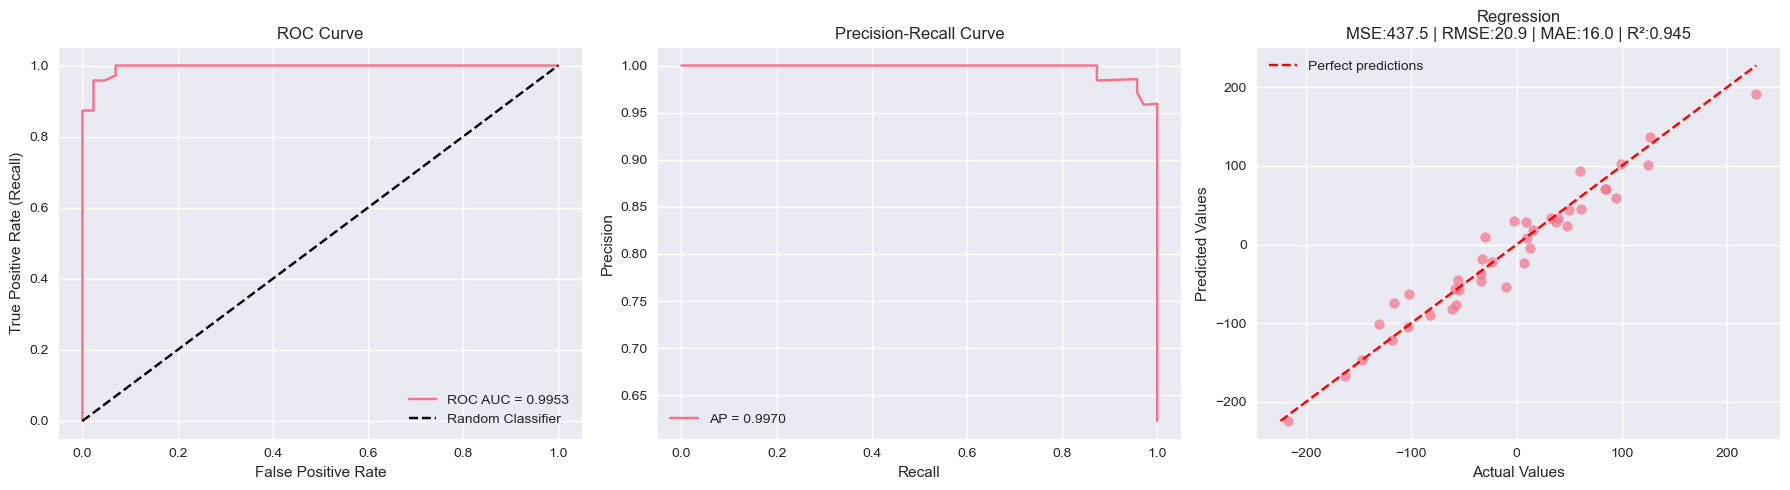


=== Regression Metrics Summary ===
MSE:  437.55  (Mean Squared Error - penalizes large errors)
RMSE: 20.92  (Root MSE - in the same units as target)
MAE:  16.04  (Mean Absolute Error - more robust to outliers)
R²:   0.9450  (Proportion of variance explained)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True)

# 2. Precision-Recall Curve (better for imbalanced data)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(recall_curve, precision_curve, label=f'AP = {ap:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True)

# 3. Regression Metrics
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg = LinearRegression()
reg.fit(X_reg_tr, y_reg_tr)
y_reg_pred = reg.predict(X_reg_te)

mse = mean_squared_error(y_reg_te, y_reg_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_reg_te, y_reg_pred)
r2 = r2_score(y_reg_te, y_reg_pred)

axes[2].scatter(y_reg_te, y_reg_pred, alpha=0.7)
min_val = min(y_reg_te.min(), y_reg_pred.min())
max_val = max(y_reg_te.max(), y_reg_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect predictions')
axes[2].set_xlabel('Actual Values')
axes[2].set_ylabel('Predicted Values')
axes[2].set_title(f'Regression\nMSE:{mse:.1f} | RMSE:{rmse:.1f} | MAE:{mae:.1f} | R²:{r2:.3f}')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print('\n=== Regression Metrics Summary ===')
print(f'MSE:  {mse:.2f}  (Mean Squared Error - penalizes large errors)')
print(f'RMSE: {rmse:.2f}  (Root MSE - in the same units as target)')
print(f'MAE:  {mae:.2f}  (Mean Absolute Error - more robust to outliers)')
print(f'R²:   {r2:.4f}  (Proportion of variance explained)')

# 4. The Imbalanced Data Problem and When to Use Which Metric

In [5]:
# Simulate imbalanced dataset (99% negative, 1% positive)
np.random.seed(42)
n_total = 1000
y_imbalanced = np.zeros(n_total, dtype=int)
y_imbalanced[:10] = 1  # Only 10 positives

# Dummy model: always predicts 0
y_dummy = np.zeros(n_total, dtype=int)

print('=== Imbalanced Dataset Demo ===')
print(f'Positive samples: {y_imbalanced.sum()} ({y_imbalanced.mean()*100:.1f}%)')
print(f'Negative samples: {(y_imbalanced==0).sum()} ({(y_imbalanced==0).mean()*100:.1f}%)')
print(f'\nDummy model (always predicts negative):')
print(f'  Accuracy:  {accuracy_score(y_imbalanced, y_dummy):.4f}  ← Seems great!')
print(f'  Recall:    {recall_score(y_imbalanced, y_dummy, zero_division=0):.4f}  ← Terrible!')
print(f'  F1-Score:  {f1_score(y_imbalanced, y_dummy, zero_division=0):.4f}  ← Reveals the truth')

print('\n=== Metric Selection Guide ===')
guide = [
    ('Balanced Classification', 'Accuracy, F1-Macro'),
    ('Imbalanced Classification', 'F1-Score, ROC-AUC, Precision-Recall AUC'),
    ('Medical Diagnosis (minimize FN)', 'Recall/Sensitivity'),
    ('Spam Detection (minimize FP)', 'Precision'),
    ('Regression (minimize big errors)', 'MSE, RMSE'),
    ('Regression (robust to outliers)', 'MAE'),
    ('Regression (explained variance)', 'R²'),
]

for scenario, metric in guide:
    print(f'  {scenario:<40}: {metric}')

=== Imbalanced Dataset Demo ===
Positive samples: 10 (1.0%)
Negative samples: 990 (99.0%)

Dummy model (always predicts negative):
  Accuracy:  0.9900  ← Seems great!
  Recall:    0.0000  ← Terrible!
  F1-Score:  0.0000  ← Reveals the truth

=== Metric Selection Guide ===
  Balanced Classification                 : Accuracy, F1-Macro
  Imbalanced Classification               : F1-Score, ROC-AUC, Precision-Recall AUC
  Medical Diagnosis (minimize FN)         : Recall/Sensitivity
  Spam Detection (minimize FP)            : Precision
  Regression (minimize big errors)        : MSE, RMSE
  Regression (robust to outliers)         : MAE
  Regression (explained variance)         : R²


# Conclusions and Key Takeaways
Model evaluation is the process of choosing between models, tuning hyperparameters, and estimating how well the selected model will perform on future, unseen data. The choice of evaluation metrics depends heavily on the specific business problem.
- **Classification Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC.
- **Regression Metrics**: MAE, MSE, RMSE, R-squared.
- Utilizing Confusion Matrices helps heavily in understanding the specific types of errors a classification model makes.

# Pros and Cons
**Pros of Rigorous Evaluation:**
- Ensures the model generalizes rather than just memorizes.
- Aligns model performance with business objectives (e.g., minimizing false negatives in medical testing).

**Cons & Challenges:**
- Optimizing for the wrong metric can lead to counterproductive business outcomes.
- High accuracy on imbalanced datasets is often misleading, requiring complex metric selection.

# 15 Interview Questions and Answers

1. **What is a Confusion Matrix?**
   *Answer*: A table used to describe the performance of a classification model. It shows True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

2. **Define Precision and Recall.**
   *Answer*: Precision is TP / (TP + FP) – out of all predicted positives, how many were actually positive. Recall (Sensitivity) is TP / (TP + FN) – out of all actual positives, how many did we correctly predict.

3. **When would you prioritize Precision over Recall?**
   *Answer*: When the cost of a False Positive is very high. For example, spam email filtering. You don't want to flag a crucial work email as spam (False Positive).

4. **When would you prioritize Recall over Precision?**
   *Answer*: When the cost of a False Negative is critical. For example, cancer detection. Missing a cancer diagnosis (False Negative) is much worse than a false alarm.

5. **What is the F1-Score?**
   *Answer*: The harmonic mean of Precision and Recall: 2 * (Precision * Recall) / (Precision + Recall). It's used when you want to achieve a balance between both metrics, especially with imbalanced datasets.

6. **Why use the harmonic mean instead of arithmetic mean for F1-score?**
   *Answer*: The harmonic mean severely punishes extreme values. If a model has a recall of 1.0 and precision of 0.0, the arithmetic mean is 0.5, but the harmonic mean is 0, which accurately reflects that the model is useless.

7. **What is the ROC Curve?**
   *Answer*: The Receiver Operating Characteristic curve plots the True Positive Rate (Recall/Sensitivity) against the False Positive Rate (1 - Specificity) at various threshold settings.

8. **What does the AUC signify?**
   *Answer*: The Area Under the ROC Curve (AUC) measures the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 is perfect; 0.5 is random guessing.

9. **Is Accuracy a good metric for imbalanced datasets?**
   *Answer*: No. If 99% of transactions are legitimate and 1% are fraud, a model that simply predicts "legitimate" every single time will have 99% accuracy but is completely useless at detecting fraud.

10. **What is Mean Absolute Error (MAE)?**
    *Answer*: The average of the absolute differences between predictions and actual values. It gives an idea of the magnitude of the error but no idea of the direction.

11. **What is the difference between MSE and RMSE?**
    *Answer*: Mean Squared Error squares the differences before averaging, which heavily penalizes larger errors. Root Mean Squared Error (RMSE) takes the square root of MSE, bringing the metric back to the original units of the target variable.

12. **When should you use MAE over RMSE?**
    *Answer*: MAE is more robust to outliers since larger errors don't get exponentially penalized by squaring them. If large errors/outliers are likely to be bad data chunks rather than something the model should focus on, MAE is better.

13. **What is R-squared (Coefficient of Determination)?**
    *Answer*: It represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model. Better models have R-squared closer to 1.

14. **What is Adjusted R-squared?**
    *Answer*: Unlike R-squared, which increases as you add more features (even useless ones), Adjusted R-squared penalizes the addition of independent variables that do not actually significantly improve the model's explanatory power.

15. **What is the PR Curve and when is it preferred over ROC?**
    *Answer*: The Precision-Recall curve plots Precision vs. Recall. It is often preferred over ROC when dealing with highly imbalanced datasets where the positive class is very rare, as ROC can be overly optimistic due to the massive number of True Negatives.
